# Underwater Object Detection in One Hour

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Spiffical/fathomnet-underwater-vision-tutorial/blob/main/notebooks/fathomnet_underwater_object_detection_one_hour.ipynb)

This notebook is built for a **one-hour class**, but it is also complete enough to work through independently afterward. It teaches **object detection**: finding each object in an image and drawing a rectangular **bounding box** around it.

The images and annotations are derived from the [FathomNet Database](https://database.fathomnet.org/fathomnet/#/), a global, expert-annotated collection created to support marine science and underwater machine learning. Underwater imagery is unusually challenging because water changes colour and contrast, artificial lights create uneven illumination, animals may be small or partly hidden, and the seafloor contains complex textures.

The central investigation is **domain shift**, meaning that the images used to develop a model differ from the images on which we want to use it:

1. an ordinary pretrained **You Only Look Once (YOLO)** detector works well on a familiar ground-level photograph;
2. the unchanged model misses or misnames underwater organisms;
3. we inspect YOLO bounding-box annotations and **fine-tune** the same model—continue its training—on 32 underwater images;
4. we download and compare a larger FathomNet-trained YOLO model called Megalodon; and
5. we finish with **Segment Anything Model 3 (SAM3)**, which can use text prompts to request object masks.

The appendices extend the same workflow to class-specific detection and conventional instance segmentation. Review [FathomNet data use](https://www.fathomnet.org/datause) and the bundle's `licenses/attribution.csv` before redistributing imagery.

Reference links:

- FathomNet Database: https://database.fathomnet.org/fathomnet/#/
- FathomNet data use policy: https://www.fathomnet.org/datause
- Ultralytics prediction guide: https://docs.ultralytics.com/modes/predict/
- Ultralytics training guide: https://docs.ultralytics.com/modes/train/
- Ultralytics detection format: https://docs.ultralytics.com/datasets/detect/
- Ultralytics segmentation format: https://docs.ultralytics.com/datasets/segment/
- Megalodon 2024 YOLO11 checkpoint: https://huggingface.co/FathomNet/megalodon-2024-yolov11
- SAM3 repository: https://github.com/facebookresearch/sam3
- SAM3 image predictor example: https://github.com/facebookresearch/sam3/blob/main/examples/sam3_image_predictor_example.ipynb

## Learning goals and 60-minute map

By the end, you should be able to:

- distinguish one-class detection, multi-class detection, and instance-segmentation targets;
- read a YOLO detection row: `class_id x_center y_center width height`;
- explain why a detector trained on general photographs can fail under domain shift;
- fine-tune vanilla `yolo11n.pt` on a small underwater dataset and interpret the result cautiously;
- download and use a recent FathomNet YOLO checkpoint (a saved model file); and
- describe what is new about text-prompted SAM3 segmentation.

Suggested instructor timing:

| Time | Topic |
|---:|---|
| 0–7 min | setup, images, and the task |
| 7–15 min | Zidane warm-up and underwater domain shift |
| 15–28 min | bounding boxes and dataset design |
| 28–44 min | fine-tune vanilla YOLO and compare results |
| 44–52 min | download and run FathomNet Megalodon |
| 52–60 min | SAM3 finale and takeaways |

Prerequisites: comfort with Python, Git, and Jupyter or Google Colab. No prior computer-vision experience is assumed.

Run the notebook from top to bottom because later cells reuse variables created earlier. Questions are followed immediately by answer cells for independent study. The confidence-threshold exercise and both appendices are optional during the live hour but remain runnable afterward.

## Essential vocabulary

- A **model** is a function with adjustable numbers that maps an input, such as an image, to predictions. Those learned numbers are called **parameters** or **weights**.
- **Training** adjusts the weights using labelled examples. **Inference** uses fixed weights to make predictions on new images.
- A **pretrained model** has already learned from another dataset. **Fine-tuning** continues training it on a new dataset or task. **Vanilla YOLO** means the ordinary general-image checkpoint before any underwater fine-tuning.
- A **class** is a category the model can predict. A **label** or **annotation** is the recorded answer for one training example. **Ground truth** means the annotations used as the reference when evaluating predictions.
- **Object detection** predicts a class and bounding box for each object. **Segmentation** predicts pixels or regions; **instance segmentation** predicts a separate region, called a **mask**, for each individual object.
- **YOLO** stands for **You Only Look Once**. In this notebook it refers to Ultralytics YOLO models, which predict many object boxes in one pass through an image.
- **COCO** stands for **Common Objects in Context**, a standard dataset used to train and compare vision models. It contains 80 everyday object classes such as person, tie, and bird. The vanilla YOLO checkpoint used here was trained on those classes.
- A **confidence score** is the model's strength of belief in one prediction. A **confidence threshold** hides predictions below a chosen score; it does not turn the remaining predictions into guaranteed facts.
- A **checkpoint** is a file containing saved model weights. PyTorch checkpoints commonly end in `.pt`.

Terms specific to data splits, optimisation, and evaluation are introduced immediately before they are used.

## 1. Setup

The first cell locates the project root. In Colab it clones the repository into `/content` when needed; locally, launch Jupyter from the repository or one of its subdirectories.

### In Google Colab: select a GPU

Before running any setup code:

1. Choose **Runtime → Change runtime type**.
2. Under **Hardware accelerator**, select **T4 GPU** or another available NVIDIA GPU.
3. Click **Save**, then run the notebook from the top.

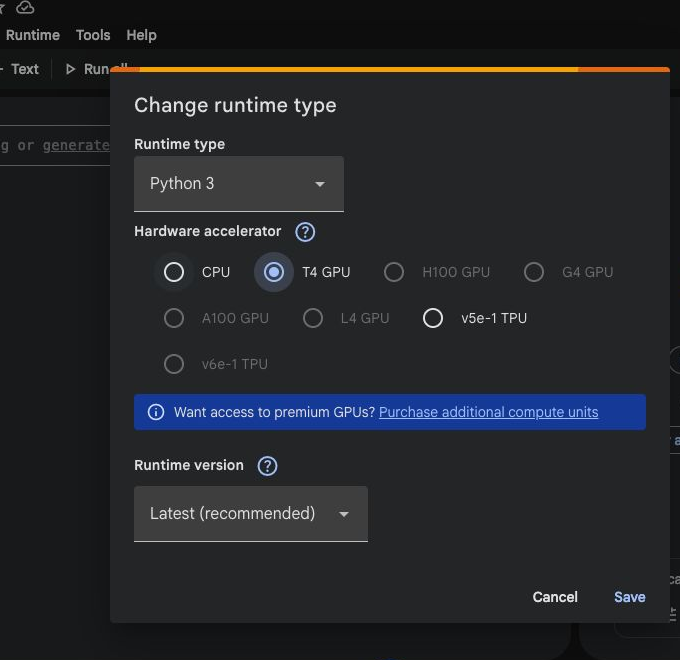

The setup report should identify a CUDA device and print `Live fine-tuning: True`. GPU availability depends on your Colab account and current capacity. If no GPU is available, the notebook still runs using its clearly labelled saved training results.

In [ ]:
from pathlib import Path
import json
import os
import subprocess
import sys

GITHUB_REPO_URL = "https://github.com/Spiffical/fathomnet-underwater-vision-tutorial"
GITHUB_BRANCH = "main"
PROJECT_DIR_NAME = "fathomnet_underwater_vision_tutorial"

def candidate_roots():
    cwd = Path.cwd().resolve()
    yield cwd
    yield from cwd.parents
    yield Path("/content") / PROJECT_DIR_NAME

REPO_ROOT = next(
    (path for path in candidate_roots() if (path / "scripts").exists() and (path / "notebooks").exists()),
    None,
)

if REPO_ROOT is None and "google.colab" in sys.modules:
    REPO_ROOT = Path("/content") / PROJECT_DIR_NAME
    if not REPO_ROOT.exists():
        subprocess.check_call([
            "git", "clone", "--depth", "1", "--branch", GITHUB_BRANCH,
            f"{GITHUB_REPO_URL}.git", str(REPO_ROOT),
        ])

if REPO_ROOT is None:
    raise RuntimeError("Repository not found. Start Jupyter inside the cloned tutorial repository.")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repository: {REPO_ROOT}")

### Dependencies, runtime, and data

A **runtime** is the Python process and hardware executing the notebook. The main software packages are:

- **PyTorch:** the machine-learning framework that stores the model and computes weight updates;
- **Torchvision:** image utilities designed to work with PyTorch; and
- **Ultralytics:** the Python package that provides the YOLO model, training, prediction, and evaluation interface used below.

Colab installs the tested, **pinned** versions—fixed versions chosen for reproducibility—of PyTorch 2.11, Torchvision 0.26, and Ultralytics 8.4.41. Local users should first run `pip install -r requirements.txt` in a Python 3.12 environment.

Training is fastest on a **graphics processing unit (GPU)**. NVIDIA GPUs use **Compute Unified Device Architecture (CUDA)**; Apple Silicon uses **Metal Performance Shaders (MPS)**. A **central processing unit (CPU)** can run inference but would make the live fine-tuning demonstration slow. The setup therefore chooses CUDA first, then MPS, then CPU. CPU-only runs use a clearly labelled saved reference result. To force that reference path, set `RUN_LIVE_FINE_TUNING = False` after this cell.

The setup fixes the random seed at `42` to reduce run-to-run variation, although small numerical differences can still occur across hardware.

In [ ]:
from scripts.tutorial_setup import (
    dependency_versions,
    download_tutorial_bundle,
    ensure_dependencies,
    set_reproducible_seed,
)

IN_COLAB = "google.colab" in sys.modules
DEPENDENCY_STATUS = ensure_dependencies(install=IN_COLAB, extra_pip_args=("--quiet",))
print(json.dumps(dependency_versions(), indent=2))

import torch
from ultralytics import YOLO

if torch.cuda.is_available():
    DEVICE = 0
    DEVICE_LABEL = torch.cuda.get_device_name(0)
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
    DEVICE_LABEL = "Apple Metal Performance Shaders (MPS)"
else:
    DEVICE = "cpu"
    DEVICE_LABEL = "CPU"

RUN_LIVE_FINE_TUNING = DEVICE != "cpu"
set_reproducible_seed(42)

BUNDLE_ROOT = download_tutorial_bundle(
    bundle_url=(
        "https://github.com/Spiffical/fathomnet-underwater-vision-tutorial/raw/main/"
        "data/fathomnet_underwater_tutorial_bundle.zip"
    ),
    bundle_zip_path=REPO_ROOT / "data" / "fathomnet_underwater_tutorial_bundle.zip",
    output_dir=REPO_ROOT / "data" / "fathomnet_underwater_tutorial_bundle",
)

print(f"Device: {DEVICE_LABEL}")
print(f"Live fine-tuning: {RUN_LIVE_FINE_TUNING}")
print(f"Data bundle: {BUNDLE_ROOT}")

### Setup success checks and common fixes

The cell is ready when it prints a device, `Live fine-tuning: True` or `False`, and a path to the data bundle.

- The first run needs internet access for model checkpoints and, in Colab, the repository.
- If package installation requests a Colab restart, restart the session and rerun from the top.
- On CPU, YOLO inference remains live while fine-tuning uses the labelled saved reference path.

## 2. Two underwater scenes

We will reuse two evaluation scenes throughout the lesson so changes are easy to see. Neither scene is included in the 32-image fine-tuning subset.

- The first has a fish plus several structurally different **benthic** (seafloor-associated) organisms, including sponge-like forms.
- The second has two visibly distinct animals: a crab and a small isopod-like animal. Isopods are crustaceans related to crabs and shrimp.

We chose these scenes because each contains several visibly different creatures. That makes misses, duplicate boxes, incorrect labels, and differences between text prompts easier to spot.

In [ ]:
from scripts.tutorial_data import get_task_paths
from scripts.tutorial_viz import show_image_grid

DETECT_ROOT = get_task_paths("detect", BUNDLE_ROOT)["root"]
SCENE_IDS = [
    "74e42388-95e0-4be4-8bd0-230bca26e682",
    "e7371b25-f074-48ac-a6ef-b16ea241a4aa",
]
SCENE_IMAGES = [DETECT_ROOT / "images" / "val" / f"{scene_id}.jpg" for scene_id in SCENE_IDS]
SCENE_LABELS = [DETECT_ROOT / "labels" / "val" / f"{scene_id}.txt" for scene_id in SCENE_IDS]

show_image_grid(
    SCENE_IMAGES,
    titles=["fish, sponges, and other benthos", "crab and isopod-like animal"],
    columns=2,
    figsize=(13, 5),
)

## 3. Zidane warm-up: what vanilla YOLO already knows

`yolo11n.pt` is the filename of the starting checkpoint: `11` identifies the YOLO model generation, `n` means the small **nano** model size, and `.pt` identifies a PyTorch checkpoint. It is pretrained on the 80 COCO object classes. The Zidane image is a quick sanity check: if YOLO finds the people and tie, we know that model loading, inference, and plotting are working.

In the prediction call, `conf=0.25` sets the confidence threshold, `imgsz=640` resizes the longest working dimension to the model's input size, and `device=DEVICE` selects the available hardware. Predictions below the confidence threshold are hidden.

In [ ]:
from urllib.request import urlretrieve
import matplotlib.pyplot as plt

ASSET_DIR = REPO_ROOT / "tmp" / "one_hour_assets"
ASSET_DIR.mkdir(parents=True, exist_ok=True)
ZIDANE_IMAGE = ASSET_DIR / "zidane.jpg"
if not ZIDANE_IMAGE.exists():
    urlretrieve("https://ultralytics.com/images/zidane.jpg", ZIDANE_IMAGE)

vanilla_model = YOLO("yolo11n.pt")
zidane_result = vanilla_model.predict(
    ZIDANE_IMAGE, imgsz=640, conf=0.25, device=DEVICE, verbose=False
)[0]

print([
    (zidane_result.names[int(class_id)], round(float(score), 2))
    for class_id, score in zip(zidane_result.boxes.cls, zidane_result.boxes.conf)
])
plt.figure(figsize=(9, 5))
# Ultralytics returns blue-green-red (BGR) channel order; Matplotlib expects
# red-green-blue (RGB), so [..., ::-1] reverses the three colour channels.
plt.imshow(zidane_result.plot()[..., ::-1])
plt.axis("off")
plt.title("Vanilla YOLO11n: a familiar ground-level image")
plt.show()

### Question

The model finds people and a tie. Does that imply it should also find a fish, crab, sponge, or sea star?

### Answer

No. Pretraining supplies useful **features**—reusable visual patterns such as edges, textures, and shapes—but the COCO class list and image distribution are mostly terrestrial. An image **distribution** describes which colours, viewpoints, backgrounds, object sizes, and categories commonly occur. Underwater colour, illumination, texture, object scale, and target categories are different. This change between development data and intended-use data is domain shift.

### Run the same untouched model underwater

We lower the threshold to `0.20` so weak and wrong guesses remain visible. A failure can be a **miss** (a labelled object receives no suitable box), a **false positive** (a box is predicted where the reference labels do not support one), or a wrong class name. The class names below still come from COCO; we have not fine-tuned anything yet. `max_det=10` caps the displayed predictions at ten per image so a low threshold cannot make the figure unreadable.

In [ ]:
UNDERWATER_CONF = 0.20
vanilla_underwater_results = vanilla_model.predict(
    SCENE_IMAGES,
    imgsz=640,
    conf=UNDERWATER_CONF,
    max_det=10,
    device=DEVICE,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, result, scene_id in zip(axes, vanilla_underwater_results, SCENE_IDS):
    ax.imshow(result.plot()[..., ::-1])
    ax.axis("off")
    names = [result.names[int(class_id)] for class_id in result.boxes.cls]
    ax.set_title(f"{scene_id[:8]} — vanilla labels: {names or ['none']}")
plt.tight_layout()
plt.show()

### Expected observation

On the tested stack, vanilla YOLO returns no boxes for the first scene and calls the crab/isopod objects **birds** in the second. Exact scores can vary slightly by hardware, but the qualitative domain mismatch should be the same.

Next, we will fine-tune this same model using underwater annotations and compare its predictions before and after training.

## 4. What supervision does object detection need?

During training, the labels provide the model's **supervision**. For object detection, each label row gives the class and bounding box of one object:

Each non-empty YOLO detection label row is:

`class_id x_center y_center width height`

- `class_id` is an integer identifying the target class;
- `x_center` and `y_center` locate the box centre; and
- `width` and `height` specify the box size.

The four geometry values are **normalised**: horizontal measurements are divided by image width and vertical measurements by image height, so every value lies in `[0, 1]` regardless of pixel resolution.

We merge every annotated category into one class, **underwater object** (class `0`). The model can learn where objects are, but not their biological identities. This is a **one-class** or **binary object-detection** task.

In [ ]:
from scripts.tutorial_viz import draw_yolo_boxes

for label_path in SCENE_LABELS:
    print(label_path.name)
    print(label_path.read_text().strip() or "<empty label>")
    print()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, image_path, label_path in zip(axes, SCENE_IMAGES, SCENE_LABELS):
    draw_yolo_boxes(image_path, label_path, class_names={0: "underwater object"}, ax=ax)
    ax.set_title(f"held-out truth — {label_path.stem[:8]}")
plt.tight_layout()
plt.show()

### Question

A row contains `x_center=0.75` and `width=0.20`. What horizontal fraction of the image does the box cover?

### Answer

The left edge is `0.75 - 0.20/2 = 0.65`; the right edge is `0.75 + 0.20/2 = 0.85`. Multiply those values by the image width to obtain pixel coordinates.

Normalisation lets the same annotation format work across different image resolutions.

## 5. Build a deliberately small fine-tuning set

Supervised machine learning normally separates data by role:

- the **training set** supplies examples used to update model weights;
- the **validation set** is kept out of weight updates and is used to compare settings and estimate **generalisation**, meaning performance on new data; and
- a **test set**, when available, is reserved for a final evaluation after all modelling choices are fixed.

This compact dataset contains training and validation splits but no separate test split. For the live demonstration we copy **24 positive images**, each containing at least one labelled object, and **8 negative or background-only images** with empty label files from the 80-image training split. The selection is **deterministic**, meaning the same inputs produce the same selected subset each time. All 20 validation images remain held out from weight updates.

The helper also writes a YAML dataset configuration containing the training and validation paths and class names. `FINE_TUNE_YAML` is the path to that file.

Why include empty labels? If every training frame contains a labelled object, a tiny model can begin treating any underwater texture as foreground. Negative frames provide examples where the correct answer is “no box.”

This tiny subset is enough for a live demonstration, but not for a scientific evaluation. A scientific study would use more varied data and a separate test set whose image origins have been checked to prevent overlap with training data.

In [ ]:
from scripts.tutorial_data import (
    make_detection_finetune_dataset,
    validate_yolo_dataset,
)

FINE_TUNE_ROOT = REPO_ROOT / "tmp" / "one_hour_finetune_subset"
FINE_TUNE_YAML = make_detection_finetune_dataset(
    DETECT_ROOT,
    FINE_TUNE_ROOT,
    positive_train_images=24,
    negative_train_images=8,
    val_images=None,
)
subset_report = validate_yolo_dataset(FINE_TUNE_YAML, task="detect")
print(json.dumps(subset_report, indent=2))

## 6. Fine-tune the vanilla detector

The important line is `YOLO("yolo11n.pt")`: this starts from the ordinary COCO-pretrained weights used in the warm-up, not from a FathomNet checkpoint. This is **transfer learning**: reuse knowledge learned on one dataset, then adapt it to a related task.

Training repeatedly compares predictions with annotations using a numerical **loss function**, which assigns a larger penalty to worse predictions. A **gradient** describes how a small weight change would change the loss. An **optimizer** uses those gradients to update the weights in a direction that should reduce the loss. The main settings are:

- `epochs=35`: an **epoch** is one complete pass through the training set;
- `batch=8`: a **batch** is the group of images used for one weight-update step, so 32 images create four batches per epoch;
- `imgsz=416`: the working image size, chosen as a speed/detail compromise;
- `lr0=0.001`: the initial **learning rate**, which controls the size of weight updates; and
- `optimizer="AdamW"`: the specific update rule used to apply those changes.

Thirty-five epochs sounds large, but each epoch contains only four batches. Per-epoch validation is disabled to keep the demonstration short; one validation pass runs at the end. The run saves `last.pt` for the final epoch and `best.pt` for the checkpoint Ultralytics selects for evaluation.

Live fine-tuning should take a few minutes on a supported GPU, although exact timing depends on the hardware. CPU-only execution skips training and uses the saved results from a previous run below.

Ultralytics applies **non-maximum suppression (NMS)** after raw prediction to remove redundant, highly overlapping boxes. Some MPS runs print an `NMS time limit exceeded` warning during validation. If the cell still completes and prints final metrics, this is a speed warning in that after-prediction step rather than a failed training run.

### Detection metrics used below

A predicted box must first be matched to a ground-truth box. Box overlap is measured with **intersection over union (IoU)**:

$$\mathrm{IoU}(A,B)=\frac{|A\cap B|}{|A\cup B|}.$$

An IoU of `0` means no overlap; `1` means identical boxes. At a chosen confidence and IoU threshold:

- a **true positive (TP)** is a prediction matched to a ground-truth object;
- a **false positive (FP)** is an unmatched prediction; and
- a **false negative (FN)** is a ground-truth object the model missed.

$$\mathrm{precision}=\frac{TP}{TP+FP}, \qquad
\mathrm{recall}=\frac{TP}{TP+FN}.$$

**Precision** asks, “Of the boxes predicted, how many were correct?” **Recall** asks, “Of the labelled objects, how many were found?”

**Average precision (AP)** summarises the precision–recall trade-off as the confidence threshold changes. **Mean average precision (mAP)** averages AP across classes. Because this notebook has one class, that class is the only contributor to the mean. `mAP50` uses IoU `0.50`; `mAP50-95` averages results from IoU `0.50` through `0.95` and therefore demands more precise box placement.

In [ ]:
FINE_TUNE_EPOCHS = 35
FINE_TUNE_IMGSZ = 416
FINE_TUNE_BATCH = 8
FINE_TUNE_SUMMARY = None
fine_tuned_model = None

if RUN_LIVE_FINE_TUNING:
    fine_tuned_model = YOLO("yolo11n.pt")  # vanilla COCO-pretrained checkpoint
    train_result = fine_tuned_model.train(
        data=str(FINE_TUNE_YAML),
        epochs=FINE_TUNE_EPOCHS,
        imgsz=FINE_TUNE_IMGSZ,
        batch=FINE_TUNE_BATCH,
        lr0=0.001,
        optimizer="AdamW",
        workers=0,
        device=DEVICE,
        project=str(REPO_ROOT / "tmp" / "one_hour_training"),
        name="vanilla_yolo11n_underwater_32",
        exist_ok=True,
        save=True,
        val=False,
        cache="disk",
        plots=False,
        verbose=False,
        seed=42,
    )
    save_dir = Path(fine_tuned_model.trainer.save_dir)
    best_path = save_dir / "weights" / "best.pt"
    fine_tuned_model = YOLO(best_path)
    validation = fine_tuned_model.val(
        data=str(FINE_TUNE_YAML),
        imgsz=FINE_TUNE_IMGSZ,
        batch=FINE_TUNE_BATCH,
        workers=0,
        device=DEVICE,
        plots=False,
        verbose=False,
    )
    FINE_TUNE_SUMMARY = {
        "mode": "live",
        "checkpoint": str(best_path),
        "precision": round(float(validation.box.mp), 3),
        "recall": round(float(validation.box.mr), 3),
        "mAP50": round(float(validation.box.map50), 3),
        "mAP50-95": round(float(validation.box.map), 3),
    }
else:
    FINE_TUNE_SUMMARY = {
        "mode": "saved results from a previous run (exact notebook recipe)",
        "precision": 0.410,
        "recall": 0.484,
        "mAP50": 0.276,
        "mAP50-95": 0.161,
    }

print(json.dumps(FINE_TUNE_SUMMARY, indent=2))

### If training does not fit the available memory

An “out of memory” error means the accelerator cannot hold the current model, images, and batch simultaneously. First reduce `FINE_TUNE_BATCH` from `8` to `4` or `2`. If necessary, reduce `FINE_TUNE_IMGSZ` from `416` to `320`; smaller images use less memory but can make small organisms harder to detect. Do not move validation images into training to improve the metric—that would invalidate the held-out evaluation.

Exact scores can differ slightly across CUDA and MPS because some numerical operations are implemented differently. The expected qualitative behaviour is more stable: the terrestrial class names disappear, boxes begin to overlap underwater objects, and errors remain because the training set is tiny.

### Before, after, and truth

Start with the images rather than the summary metric. Do the new boxes land on real objects in the held-out scenes? The comparison uses a low `0.20` display threshold because this tiny fine-tune has deliberately limited data and training.

Green boxes are ground truth. Prediction labels change from COCO categories such as `bird` to the one fine-tuning class, `underwater object`.

In [ ]:
from matplotlib import patches
from PIL import Image

# Saved, tested reference detections are used only on CPU-only runtimes.
# Coordinates use [x_min, y_min, x_max, y_max] pixels in the original image.
REFERENCE_FINE_TUNE_DETECTIONS = {
    SCENE_IDS[0]: {
        "boxes": [
            [1505, 469, 1764, 838],
            [615, 614, 942, 1076],
            [0, 900, 172, 1058],
            [2, 449, 485, 833],
        ],
        "scores": [0.668, 0.513, 0.249, 0.205],
    },
    SCENE_IDS[1]: {
        "boxes": [[300, 119, 439, 193], [467, 136, 524, 182]],
        "scores": [0.681, 0.383],
    },
}

if fine_tuned_model is not None:
    fine_tuned_results = fine_tuned_model.predict(
        SCENE_IMAGES,
        imgsz=FINE_TUNE_IMGSZ,
        conf=UNDERWATER_CONF,
        max_det=10,
        device=DEVICE,
        verbose=False,
    )
else:
    fine_tuned_results = None

def show_reference_prediction(ax, image_path, reference):
    ax.imshow(Image.open(image_path).convert("RGB"))
    for box, score in zip(reference["boxes"], reference["scores"]):
        x0, y0, x1, y1 = box
        ax.add_patch(patches.Rectangle(
            (x0, y0), x1 - x0, y1 - y0,
            fill=False, edgecolor="deepskyblue", linewidth=2,
        ))
        ax.text(x0, y0, f"underwater object {score:.2f}", color="black", backgroundcolor="deepskyblue")
    ax.axis("off")

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for row, (scene_id, image_path, label_path, vanilla_result) in enumerate(zip(
    SCENE_IDS, SCENE_IMAGES, SCENE_LABELS, vanilla_underwater_results
)):
    axes[row, 0].imshow(vanilla_result.plot()[..., ::-1])
    axes[row, 0].axis("off")
    axes[row, 0].set_title("before: vanilla COCO model")

    if fine_tuned_results is not None:
        axes[row, 1].imshow(fine_tuned_results[row].plot()[..., ::-1])
        axes[row, 1].axis("off")
    else:
        show_reference_prediction(axes[row, 1], image_path, REFERENCE_FINE_TUNE_DETECTIONS[scene_id])
    axes[row, 1].set_title("after: 32 underwater training images")

    draw_yolo_boxes(image_path, label_path, class_names={0: "truth"}, ax=axes[row, 2], color="lime")
    axes[row, 2].set_title("held-out ground truth")

plt.tight_layout()
plt.show()

### How to read the result

The saved results come from an earlier run of this exact recipe. That run reached about `0.27` mAP@0.5 on the held-out validation set. In the selected scenes, the new boxes begin to overlap real underwater objects, and the terrestrial class names disappear.

This is still a weak detector: it misses objects, produces low-confidence predictions, and retains some false positives. Thirty-two training images are enough to demonstrate adaptation, but not enough to support scientific use.

### Question

If the number of detections increases, has the detector necessarily improved?

### Answer

No. Extra boxes may add true positives, false positives, or both. Detection counts must be interpreted together with IoU matching, precision, recall, and AP. The visual comparison is also important here: it reveals *which* objects were found, where boxes overlap poorly, and whether unlabelled background received boxes.

### Self-study exercise: confidence thresholds

Rerun the next cell with thresholds such as `0.05`, `0.10`, and `0.25`. Predict before running it: which way will precision and recall usually move as the threshold increases?

In [ ]:
if fine_tuned_model is not None:
    threshold_counts = {}
    for threshold in [0.05, 0.10, 0.25]:
        result = fine_tuned_model.predict(
            SCENE_IMAGES[0], imgsz=FINE_TUNE_IMGSZ, conf=threshold,
            device=DEVICE, verbose=False,
        )[0]
        threshold_counts[threshold] = len(result.boxes)
    print(threshold_counts)
else:
    print("Reference answer: raising the threshold removes lower-scoring boxes.")

### Exercise answer

Increasing the threshold usually removes predictions. Precision often rises because weak false positives disappear, while recall often falls because some real objects also had weak scores. “Usually” matters: on a tiny sample, either metric can move irregularly.

## 7. Download and use a FathomNet-trained model

Next, instead of fine-tuning YOLO ourselves, we will download [Megalodon 2024 YOLO11](https://huggingface.co/FathomNet/megalodon-2024-yolov11), a detector already trained on public FathomNet bounding-box annotations.

The checkpoint is hosted on the **Hugging Face Hub**. We download it with `hf_hub_download(...)` and pin a specific revision so that every run uses the same weights.

The filename `mbari-megalodon-yolo11x.pt` begins with **MBARI**, the **Monterey Bay Aquarium Research Institute**, and contains `x`, meaning the extra-large YOLO11 size. Megalodon has one generic class, `item`, so it can locate prominent underwater objects but cannot identify them biologically.

In [ ]:
from huggingface_hub import hf_hub_download

MEGALODON_REPO = "FathomNet/megalodon-2024-yolov11"
MEGALODON_FILE = "mbari-megalodon-yolo11x.pt"
MEGALODON_REVISION = "403704d2d4dba9903ffbdd215648c3fc8ae6f377"

megalodon_path = hf_hub_download(
    repo_id=MEGALODON_REPO,
    filename=MEGALODON_FILE,
    revision=MEGALODON_REVISION,
)
megalodon_model = YOLO(megalodon_path)
megalodon_results = megalodon_model.predict(
    SCENE_IMAGES,
    imgsz=640,
    conf=0.25,
    max_det=20,
    device=DEVICE,
    verbose=False,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, result, scene_id in zip(axes, megalodon_results, SCENE_IDS):
    ax.imshow(result.plot()[..., ::-1])
    ax.axis("off")
    scores = [round(float(score), 2) for score in result.boxes.conf]
    ax.set_title(f"Megalodon — {len(scores)} items — scores {scores}")
plt.tight_layout()
plt.show()

### Question

Is “Megalodon finds more underwater objects than vanilla YOLO11n” a fair scientific benchmark of training data alone?

### Answer and caveats

No. At least three factors are mixed together:

- **domain data:** Megalodon was trained on public FathomNet bounding-box annotations;
- **model capacity:** it is YOLO11x, with many more learned parameters than the YOLO11n model used for the live fine-tune; and
- **possible data relationship:** these tutorial images are FathomNet-derived, so they are not guaranteed to be independent of Megalodon's training collection.

Use this comparison to see how the models behave, not to claim that one training dataset is better. A fair benchmark would keep model size, training resources, annotation rules, and test data consistent.

## 8. Finale: text-prompted segmentation with SAM3

Unlike the YOLO detectors above, **Segment Anything Model 3 (SAM3)** takes a prompt at inference time. A **text prompt** such as `"fish"` or `"sponge"` tells the model what to segment.

For each matching object instance, SAM3 can return a confidence score, a box, and a **pixel mask**: an array indicating which image pixels belong to that object. Change the prompt and you can ask for a different kind of object without retraining the model.

Live SAM3 has heavier requirements than the YOLO sections: Python 3.12 or newer, a recent CUDA-enabled build of PyTorch, the official `sam3` Python package, permission to access the model checkpoint, and a Hugging Face **access token**. A token is a private credential used to authenticate the download. Never paste a real token into a saved code or markdown cell; the helper below uses hidden input and stores it only in the current runtime. Live SAM3 is unavailable on CPU and MPS runtimes.

To keep the notebook executable everywhere:

- a prepared CUDA runtime with SAM3 installed and the `HF_TOKEN` environment variable configured runs real inference automatically; and
- other runtimes show a **label-derived teaching reference**, constructed from existing annotations and clearly marked as *not SAM3 output*.

On unsupported hardware, the next cells load a label-derived example so the plotting code still works. It is not SAM3 output and should not be interpreted as model performance. The reference is **cached**, meaning it is already saved in the data bundle. To prepare a new compatible runtime, change `INSTALL_AND_AUTHENTICATE_SAM3` to `True`, run the next cell, enter a Hugging Face read token in the hidden prompt if requested, and rerun the cell once installation is complete. In the printed status report, `sam3_importable` means that Python can locate and load the installed package.

In [ ]:
from scripts.tutorial_sam3 import (
    configure_huggingface_token,
    install_sam3_package,
    load_cached_sam3_result,
    run_sam3_text_prompt,
    sam3_can_run_live,
)
from scripts.tutorial_viz import plot_sam3_result

# For a fresh CUDA/Colab runtime, deliberately opt in once, run this cell,
# then rerun it after installation/authentication completes.
INSTALL_AND_AUTHENTICATE_SAM3 = False

if INSTALL_AND_AUTHENTICATE_SAM3:
    status = sam3_can_run_live()
    if not status["sam3_importable"]:
        install_sam3_package()
    if not status["hf_token_present"]:
        configure_huggingface_token(prompt_if_missing=True)

SAM3_STATUS = sam3_can_run_live()
USE_LIVE_SAM3 = bool(SAM3_STATUS["can_run"])
print(json.dumps(SAM3_STATUS, indent=2))
print(f"Live SAM3 inference: {USE_LIVE_SAM3}")

In [ ]:
SAM3_IMAGE_ID = SCENE_IDS[0]
SAM3_PROMPTS = ["fish", "sponge"]

for prompt in SAM3_PROMPTS:
    if USE_LIVE_SAM3:
        sam3_result = run_sam3_text_prompt(
            SCENE_IMAGES[0], prompt, confidence_threshold=0.35
        )
        title = f"LIVE SAM3 — text prompt: {prompt!r}"
    else:
        sam3_result = load_cached_sam3_result(BUNDLE_ROOT, SAM3_IMAGE_ID, prompt)
        title = f"REFERENCE LABEL PREVIEW (NOT SAM3) — prompt: {prompt!r}"

    print({
        "prompt": prompt,
        "source": sam3_result.get("source"),
        "instances": len(sam3_result.get("boxes", [])),
    })
    plot_sam3_result(
        SCENE_IMAGES[0],
        sam3_result,
        score_threshold=0.35,
        title=title,
    )

### Question

If the prompt `"echinoderm"` returns no mask, does that prove no echinoderm is present?

### Answer

No. A negative prompt result can reflect the wording, confidence threshold, object scale, **occlusion** (part of the object being hidden), domain shift, or model failure. Try synonyms and more concrete descriptions, and inspect multiple thresholds. A prompt result is a model prediction, not proof. Compare it with expert annotations before drawing conclusions.

## Takeaways

- A successful Zidane prediction verifies the model-loading, inference, and plotting steps; it does not establish underwater competence.
- Bounding-box labels provide the new supervision that changes a vanilla detector's behaviour.
- A 32-image fine-tune can create a visible domain-adaptation signal, but it is not enough to justify using the model in a real scientific workflow.
- Downloadable FathomNet models provide a strong underwater starting point, with provenance and comparison caveats.
- SAM3's text-prompt interface is genuinely different and powerful, but every prompt still needs evaluation against trustworthy labels.

For a real project, check for **data leakage**—the same image, video sequence, or near-duplicate appearing in both training and evaluation data. Retain meaningful biological classes rather than one generic object class, collect more difficult negative frames, compare model designs at similar sizes, and evaluate once on a provenance-controlled test set.

---

## Appendix A — Fine-tune YOLO to predict class names

The main lesson treats every annotated organism as the same class, `underwater object`. That makes domain adaptation easy to see, but it leaves out an important part of object detection: a detector can predict both *where* an object is and *what class* it belongs to.

Multi-class detection uses the same five-value YOLO row as one-class detection:

```text
class_id x_center y_center width height
```

Only the meaning of `class_id` changes. In the main lesson it is always `0`; here it can range from `0` to `4`.

The source COCO file contains 96 detailed FathomNet concept names, many represented by only one or two examples. That is too sparse for a useful short exercise, so this appendix maps selected concepts into five broad visual groups: `fish`, `crustacean`, `echinoderm`, `gelatinous`, and `sponge/cnidarian`. Sponges and cnidarians are biologically distinct; they share one visual workshop label here only because the dataset is small. These groups are not a biological taxonomy. A scientific project should define its classes with domain experts and keep the original concept provenance.

In [ ]:
from scripts.tutorial_data import make_coarse_multiclass_detection_dataset

COCO_JSON = get_task_paths("coco", BUNDLE_ROOT)["json"]
MULTICLASS_ROOT = REPO_ROOT / "tmp" / "appendix_multiclass_detection"
MULTICLASS_INFO = make_coarse_multiclass_detection_dataset(
    COCO_JSON,
    DETECT_ROOT,
    MULTICLASS_ROOT,
)
MULTICLASS_YAML = Path(MULTICLASS_INFO["yaml_path"])
MULTICLASS_NAMES = MULTICLASS_INFO["class_names"]
multiclass_validation = validate_yolo_dataset(MULTICLASS_YAML, task="detect")

multiclass_summary = {
    "class_names": MULTICLASS_NAMES,
    "instances": MULTICLASS_INFO["instance_counts"],
    "images_with_class": MULTICLASS_INFO["image_counts"],
    "empty_label_files": MULTICLASS_INFO["empty_label_files"],
    "small_instances_omitted": MULTICLASS_INFO["filtered_small_instances"],
    "annotations_outside_the_five_groups": sum(
        MULTICLASS_INFO["unmapped_annotation_counts"].values()
    ),
}
print(json.dumps(multiclass_summary, indent=2))
assert multiclass_validation["valid"], multiclass_validation["invalid_lines"]

The split remains the same as in the bundle: 80 training images and 20 validation images. Images without one of the five retained classes stay in the dataset with an empty label file. For this exercise they are background examples, but this would be dangerous if they contained unlabelled target objects: the model would be penalized for detecting a real object that the label file omitted.

The printed counts also reveal a serious limitation. The classes are imbalanced, and the validation split contains only one labelled fish and one labelled crustacean. This dataset can demonstrate the training mechanics, but it cannot support strong claims about class-specific accuracy.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, scene_id in zip(axes, SCENE_IDS):
    image_path = MULTICLASS_ROOT / "images" / "val" / f"{scene_id}.jpg"
    label_path = MULTICLASS_ROOT / "labels" / "val" / f"{scene_id}.txt"
    draw_yolo_boxes(
        image_path,
        label_path,
        class_names=MULTICLASS_NAMES,
        ax=ax,
        color="lime",
    )
    ax.set_title(f"five-class ground truth — {scene_id[:8]}")
plt.tight_layout()
plt.show()

### Question

What happens during evaluation if a predicted box is in the right place but has the wrong class name?

### Answer

Its location may be good, but it cannot match the ground-truth object as the correct class. It usually counts as a false positive for the predicted class and a false negative for the true class. Multi-class detection therefore has two ways to fail: poor localization and incorrect classification.

### Optional multi-class fine-tuning

We again start from `yolo11n.pt`, the vanilla COCO detector. Ultralytics reads the five class names from `MULTICLASS_YAML` and adapts the detection head from its original 80 COCO outputs to five workshop classes. The rest of the network still begins with useful pretrained visual features.

Set `RUN_MULTICLASS_FINE_TUNING = True` to run the 30-epoch exercise. It is off by default so the appendix does not add several minutes to “Run All.” If training is skipped, the cell reports saved metrics from a previous run of this recipe; it does not pretend to create live predictions.

In [ ]:
RUN_MULTICLASS_FINE_TUNING = False
MULTICLASS_EPOCHS = 30
MULTICLASS_IMGSZ = 416
MULTICLASS_BATCH = 8
multiclass_model = None

MULTICLASS_REFERENCE_SUMMARY = {
    "mode": "saved results from a previous 30-epoch appendix run",
    "precision": 0.698,
    "recall": 0.126,
    "mAP50": 0.126,
    "mAP50-95": 0.088,
    "mAP50_by_class": {
        "fish": 0.000,
        "crustacean": 0.025,
        "echinoderm": 0.004,
        "gelatinous": 0.370,
        "sponge/cnidarian": 0.231,
    },
}

if RUN_MULTICLASS_FINE_TUNING:
    multiclass_model = YOLO("yolo11n.pt")
    multiclass_model.train(
        data=str(MULTICLASS_YAML),
        epochs=MULTICLASS_EPOCHS,
        imgsz=MULTICLASS_IMGSZ,
        batch=MULTICLASS_BATCH,
        lr0=0.001,
        optimizer="AdamW",
        workers=0,
        device=DEVICE,
        project=str(REPO_ROOT / "tmp" / "appendix_training"),
        name="multiclass_yolo11n",
        exist_ok=True,
        save=True,
        val=False,
        cache="disk",
        plots=False,
        verbose=False,
        seed=42,
    )
    multiclass_save_dir = Path(multiclass_model.trainer.save_dir)
    multiclass_best = multiclass_save_dir / "weights" / "best.pt"
    multiclass_last = multiclass_save_dir / "weights" / "last.pt"
    multiclass_checkpoint = multiclass_best if multiclass_best.exists() else multiclass_last
    multiclass_model = YOLO(multiclass_checkpoint)
    multiclass_metrics = multiclass_model.val(
        data=str(MULTICLASS_YAML),
        imgsz=MULTICLASS_IMGSZ,
        batch=MULTICLASS_BATCH,
        workers=0,
        device=DEVICE,
        plots=False,
        verbose=False,
    )
    evaluated_class_ids = [int(class_id) for class_id in multiclass_metrics.box.ap_class_index]
    per_class_map50 = {
        MULTICLASS_NAMES[class_id]: round(float(ap50), 3)
        for class_id, ap50 in zip(evaluated_class_ids, multiclass_metrics.box.ap50)
    }
    multiclass_summary = {
        "mode": "live",
        "checkpoint": str(multiclass_checkpoint),
        "precision": round(float(multiclass_metrics.box.mp), 3),
        "recall": round(float(multiclass_metrics.box.mr), 3),
        "mAP50": round(float(multiclass_metrics.box.map50), 3),
        "mAP50-95": round(float(multiclass_metrics.box.map), 3),
        "mAP50_by_class": per_class_map50,
    }
else:
    multiclass_summary = MULTICLASS_REFERENCE_SUMMARY

print(json.dumps(multiclass_summary, indent=2))

In [ ]:
if multiclass_model is None:
    print(
        "Live multi-class training is off. The ground-truth figure above remains available; "
        "set RUN_MULTICLASS_FINE_TUNING = True and rerun the training cell to plot predictions."
    )
else:
    multiclass_predictions = multiclass_model.predict(
        SCENE_IMAGES,
        imgsz=MULTICLASS_IMGSZ,
        conf=0.05,
        max_det=10,
        device=DEVICE,
        verbose=False,
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, result, scene_id in zip(axes, multiclass_predictions, SCENE_IDS):
        ax.imshow(result.plot()[..., ::-1])
        ax.axis("off")
        ax.set_title(f"live five-class prediction — {scene_id[:8]}")
    plt.tight_layout()
    plt.show()

### Interpreting the saved result

The saved run is deliberately modest and uneven. Overall `mAP50` is `0.126`; the gelatinous and sponge/cnidarian groups perform better than the other three, while fish receives no correct validation detection at IoU 0.50. With so few examples—especially only one validation instance for fish and crustacean—small changes can move a per-class score sharply. The result shows that the pipeline works, not that the five classes are ready for scientific use.

### Question

Why should we report per-class metrics instead of only overall mAP?

### Answer

An average can hide failure on rare or difficult classes. Report each class's validation support alongside its precision, recall, and AP, then inspect missed objects and class confusions. If a class has only one validation example, collecting a better evaluation set is more informative than quoting another decimal place.

---

## Appendix B — Fine-tune YOLO for instance segmentation

Instance segmentation predicts a separate pixel region, called a **mask**, for every object. Compared with a box, a mask follows an object's outline and excludes more background, but masks take longer to annotate and usually require more computation to train.

A **polygon** is a closed shape defined by ordered corner points called **vertices**. YOLO segmentation rows contain `class_id` followed by normalised polygon vertices: `x1 y1 x2 y2 ...`. Connecting and filling the vertices creates the ground-truth instance mask.

The bundled segmentation labels use one generic class so we can focus on the change in geometry. Multi-class instance segmentation combines both appendices: keep the class-specific ID at the start of every polygon row, then train the segmentation model on those labels.

In [ ]:
from scripts.tutorial_viz import draw_yolo_masks

SEGMENT_PATHS = get_task_paths("segment", BUNDLE_ROOT)
SEGMENT_ROOT = SEGMENT_PATHS["root"]
SEGMENT_YAML = SEGMENT_PATHS["yaml"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for row, scene_id in enumerate(SCENE_IDS):
    detection_image = DETECT_ROOT / "images" / "val" / f"{scene_id}.jpg"
    detection_label = DETECT_ROOT / "labels" / "val" / f"{scene_id}.txt"
    segment_image = SEGMENT_ROOT / "images" / "val" / f"{scene_id}.jpg"
    segment_label = SEGMENT_ROOT / "labels" / "val" / f"{scene_id}.txt"

    draw_yolo_boxes(
        detection_image,
        detection_label,
        class_names={0: "object box"},
        ax=axes[row, 0],
        color="lime",
    )
    axes[row, 0].set_title("bounding-box ground truth")

    draw_yolo_masks(
        segment_image,
        segment_label,
        class_names={0: "object mask"},
        ax=axes[row, 1],
    )
    axes[row, 1].set_title("instance-mask ground truth")
plt.tight_layout()
plt.show()

In [ ]:
polygon_label = next(
    path
    for path in sorted((SEGMENT_ROOT / "labels" / "val").glob("*.txt"))
    if path.read_text(encoding="utf-8").strip()
)
polygon_values = [float(value) for value in polygon_label.read_text(encoding="utf-8").splitlines()[0].split()]
polygon_points = list(zip(polygon_values[1::2], polygon_values[2::2]))

print({
    "label_file": polygon_label.name,
    "class_id": int(polygon_values[0]),
    "vertex_count": len(polygon_points),
    "first_three_normalized_vertices": polygon_points[:3],
})

### Question

Why can two segmentation rows have different numbers of values?

### Answer

After the class ID, each pair of values represents one polygon vertex. A simple outline may need only a few vertices; a complex outline may need many. The coordinates are normalized by image width and height, just like the box coordinates used earlier.

### Optional segmentation fine-tuning

`yolo11n-seg.pt` is the segmentation counterpart to the detector used in the main lesson. It predicts boxes and adds a mask head that produces a shape for each detected instance. Training therefore includes both box-related and mask-related losses, and evaluation reports two families of metrics:

- **box mAP** matches predictions using bounding-box IoU; and
- **mask mAP** matches predictions using pixel-mask IoU.

Set `RUN_SEGMENTATION_FINE_TUNING = True` to run this 30-epoch exercise. With the switch off, the code plots saved curves from an earlier segmentation run included in the data bundle. Those curves are a reference, not the output of the optional recipe below, and the bundle does not include that run's checkpoint.

In [ ]:
from scripts.tutorial_viz import plot_training_curves

RUN_SEGMENTATION_FINE_TUNING = False
SEGMENTATION_EPOCHS = 30
SEGMENTATION_IMGSZ = 416
SEGMENTATION_BATCH = 8
segmentation_model = None

if RUN_SEGMENTATION_FINE_TUNING:
    segmentation_model = YOLO("yolo11n-seg.pt")
    segmentation_model.train(
        data=str(SEGMENT_YAML),
        epochs=SEGMENTATION_EPOCHS,
        imgsz=SEGMENTATION_IMGSZ,
        batch=SEGMENTATION_BATCH,
        lr0=0.001,
        optimizer="AdamW",
        workers=0,
        device=DEVICE,
        project=str(REPO_ROOT / "tmp" / "appendix_training"),
        name="binary_yolo11n_seg",
        exist_ok=True,
        save=True,
        cache="disk",
        plots=False,
        verbose=False,
        seed=42,
    )
    segmentation_save_dir = Path(segmentation_model.trainer.save_dir)
    segmentation_best = segmentation_save_dir / "weights" / "best.pt"
    segmentation_last = segmentation_save_dir / "weights" / "last.pt"
    segmentation_checkpoint = segmentation_best if segmentation_best.exists() else segmentation_last
    live_results_csv = segmentation_save_dir / "results.csv"
    segmentation_model = YOLO(segmentation_checkpoint)
    segmentation_metrics = segmentation_model.val(
        data=str(SEGMENT_YAML),
        imgsz=SEGMENTATION_IMGSZ,
        batch=SEGMENTATION_BATCH,
        workers=0,
        device=DEVICE,
        plots=False,
        verbose=False,
    )
    segmentation_summary = {
        "mode": "live",
        "checkpoint": str(segmentation_checkpoint),
        "box_mAP50": round(float(segmentation_metrics.box.map50), 3),
        "box_mAP50-95": round(float(segmentation_metrics.box.map), 3),
        "mask_mAP50": round(float(segmentation_metrics.seg.map50), 3),
        "mask_mAP50-95": round(float(segmentation_metrics.seg.map), 3),
    }
    segmentation_results_csv = live_results_csv
else:
    segmentation_summary = {
        "mode": "training skipped; showing saved curves from an earlier segmentation run"
    }
    segmentation_results_csv = (
        BUNDLE_ROOT / "cached_training" / "segmentation" / "results.csv"
    )

print(json.dumps(segmentation_summary, indent=2))
_ = plot_training_curves(
    segmentation_results_csv,
    metric_columns=[
        "metrics/mAP50(B)",
        "metrics/mAP50-95(B)",
        "metrics/mAP50(M)",
        "metrics/mAP50-95(M)",
    ],
    title="Box and mask validation metrics by epoch",
)

In [ ]:
if segmentation_model is None:
    print(
        "Live segmentation training is off. Set RUN_SEGMENTATION_FINE_TUNING = True "
        "and rerun the training cell to plot predicted masks."
    )
else:
    segmentation_predictions = segmentation_model.predict(
        SCENE_IMAGES,
        imgsz=SEGMENTATION_IMGSZ,
        conf=0.20,
        max_det=10,
        device=DEVICE,
        verbose=False,
    )
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, result, scene_id in zip(axes, segmentation_predictions, SCENE_IDS):
        ax.imshow(result.plot()[..., ::-1])
        ax.axis("off")
        ax.set_title(f"live instance-segmentation prediction — {scene_id[:8]}")
    plt.tight_layout()
    plt.show()

### Question

When is a mask worth the added annotation cost?

### Answer

Use masks when the analysis depends on object area, contour, contact between organisms, partial occlusion, shape, or precise separation from the background. If approximate location or counting is enough, boxes are usually cheaper and easier to label consistently.

The same distinction applies to evaluation: good box mAP does not guarantee good mask mAP. A prediction can surround the right object while tracing its boundary poorly.

### Putting the extensions together

- Multi-class detection changes the class ID while retaining box geometry.
- Instance segmentation changes the geometry from a box to a polygon.
- Multi-class instance segmentation makes both changes: each polygon begins with its biological class ID and is used to train `yolo11n-seg.pt`.

Before treating any of these models as scientific instruments, define the label set with experts, collect enough examples of rare classes, split data by video sequence or deployment to prevent leakage, audit unlabelled organisms, report per-class box and mask metrics, and reserve a provenance-controlled test set for final evaluation.

The [Ultralytics segmentation documentation](https://docs.ultralytics.com/tasks/segment/) provides the full prediction and training interface.